<a href="https://colab.research.google.com/github/soumensen411/statistics-for-machine-learning/blob/main/Notebook/titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
df = pd.read_csv(f'{path}/Titanic-Dataset.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df['Age'].isnull().sum()

np.int64(177)

In [ ]:
age = df['Age'].dropna()

# Q1: Calculate the mean, median, and mode of passenger ages. Are mean and median close? What does the gap tell you about the age distribution's skewness?

In [ ]:
print('mean : ', df['Age'].mean())
print('median : ', df['Age'].median())
print('mode : ', df['Age'].mode()[0])
print('skew: ',df['Age'].skew())

mean :  29.69911764705882
median :  28.0
mode :  24.0
skew:  0.38910778230082704


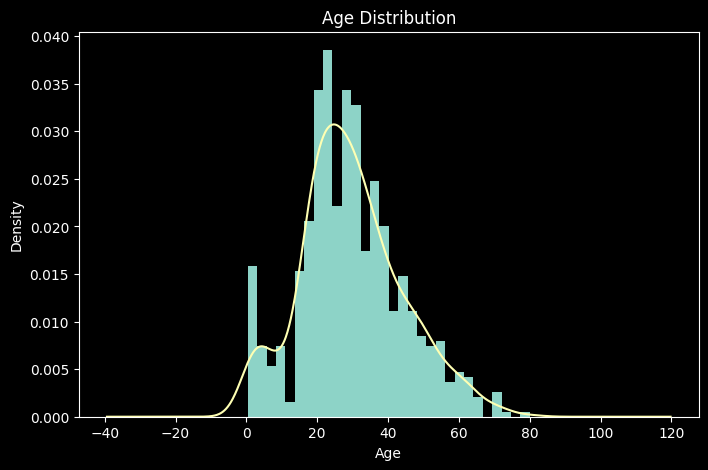

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(age,bins=30,density=True)
age.plot(kind='kde')
plt.title('Age Distribution')
plt.ylabel('Density')
plt.xlabel('Age')
plt.show()

The mean age 29.69 is higher than the median age 28.From figure it's clear age distribution are right skewed

# Q2.Compute the mean and standard deviation of Fare separately for each passenger class (Pclass). What does this tell you about the relationship between class and fare variability?

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['Fare'].isnull().sum()

np.int64(0)

In [ ]:
fare = df['Fare'].dropna()

In [ ]:
mean_fare = fare.mean()
std_fare = fare.std()
var_fare = fare.var()
print('mean: ',mean_fare)
print('variance: ',var_fare)
print('standard Deviation: ',std_fare)


upper_bound = mean_fare + 2 * std_fare
outliers = df[df['Fare'] > upper_bound]
print(f"Outliers beyond 2σ: {len(outliers)}")

mean:  32.204207968574636
variance:  2469.436845743117
standard Deviation:  49.693428597180905
Outliers beyond 2σ: 38


In [ ]:
grouped = df.groupby('Pclass')['Fare'].agg(['mean','std'])
grouped

,mean,std
Pclass,,
1,84.154687,78.380373
2,20.662183,13.417399
3,13.675550,11.778142


In [ ]:
cv = grouped['std']/grouped['mean'] * 100
print(cv)

Pclass
1    93.138451
2    64.936985
3    86.125542
dtype: float64


# Q3. What is P(survived)? What is P(survived | female)? Is survival independent of sex? Justify with numbers.

P(A|B) = P(A ∩ B) / P(B)

In [ ]:
total_survive = df['Survived'].mean()
male_survive = df[df['Sex']=='male']['Survived'].mean()
female_survive = df[df['Sex'] == 'female']['Survived'].mean()
print(f"Total survive :  {total_survive:.2f}")
print(f"Female survive : {female_survive:.2f}")
print(f"Male survive :  {male_survive:.2f}")

Total survive :  0.38
Female survive : 0.74
Male survive :  0.19


In [ ]:
print(f"P(survived)         = {total_survive:.3f}")
print(f"P(survived|female)  = {female_survive:.3f}")
print(f"P(survived|male)    = {male_survive:.3f}")

P(survived)         = 0.384
P(survived|female)  = 0.742
P(survived|male)    = 0.189


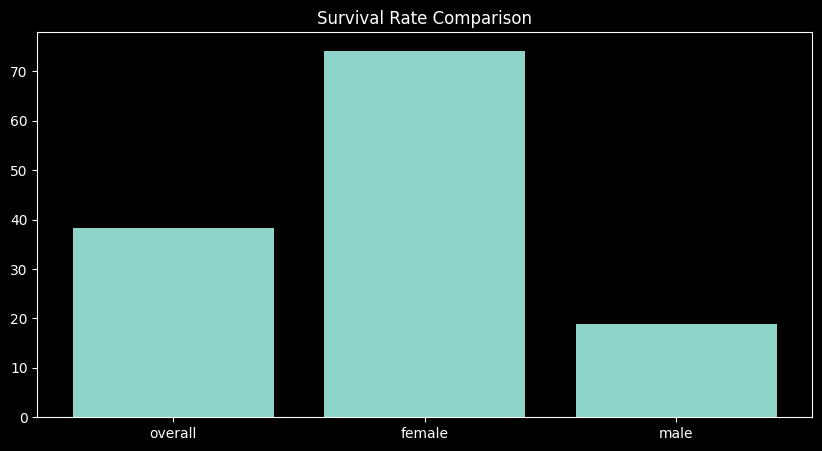

In [ ]:
labels = ['overall','female','male']
values = [total_survive,female_survive,male_survive]
values = [v * 100 for v in values]
plt.figure(figsize=(10,5))
plt.bar(labels,values)
plt.title('Survival Rate Comparison')

plt.show()

The overall survival probability is around 0.38, while the survival probability for females is significantly higher (0.74) compared to males (0.19). Since these probabilities differ greatly, survival is not independent of sex. This indicates that gender had a strong influence on survival outcomes.

# Q4 . Calculate P(survived | Pclass=1 AND sex=female) vs P(survived | Pclass=3 AND sex=male). Think of this as a Bayes update — how do two pieces of evidence combine?

In [67]:
p1_female_survival = df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]['Survived'].mean()
p3_male_survival = df[(df['Sex'] == 'male') & (df['Pclass'] == 3)]['Survived'].mean()
print(f"P(Survived | Pclass=1 & Female): {p1_female_survival:.2f}")
print(f"P(Survived | Pclass=3 & Male): {p3_male_survival:.2f}")

P(Survived | Pclass=1 & Female): 0.97
P(Survived | Pclass=3 & Male): 0.14


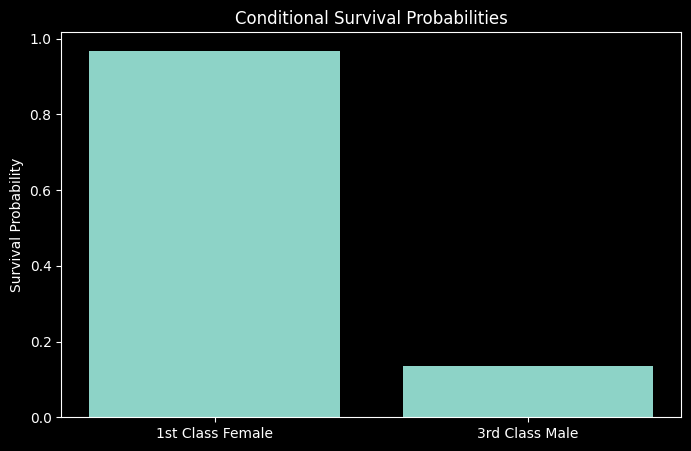

In [70]:
labels = ['1st Class Female', '3rd Class Male']
values = [p1_female_survival, p3_male_survival]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)

plt.ylabel("Survival Probability")
plt.title("Conditional Survival Probabilities")
plt.show()

# Q5. Model survival as a binomial experiment. In Pclass=2, estimate p (survival probability). For a group of 20 Pclass=2 passengers, what is the probability that exactly 8 survive? Use the binomial formula.

In [83]:
survival_probability = df[df['Pclass']==2]['Survived'].mean()
print(f"{survival_probability:.3f}")

0.473


 Number of trials → n=20 passengers

 Success → “survived”

 Probability of success → p


 Want → exactly k=8 survivors

$
formula : P(X = k) = \binom{n}{k} \cdot p^k \cdot (1 - p)^{n - k}
$

In [86]:
from math import comb

n = 20
k = 8

p = df[df['Pclass'] == 2]['Survived'].mean()
prob = comb(n, k) * (p**k) * ((1-p)**(n-k))
print(f"P(X = 8 survivors out of 20): {prob:.5f}")

P(X = 8 survivors out of 20): 0.14499


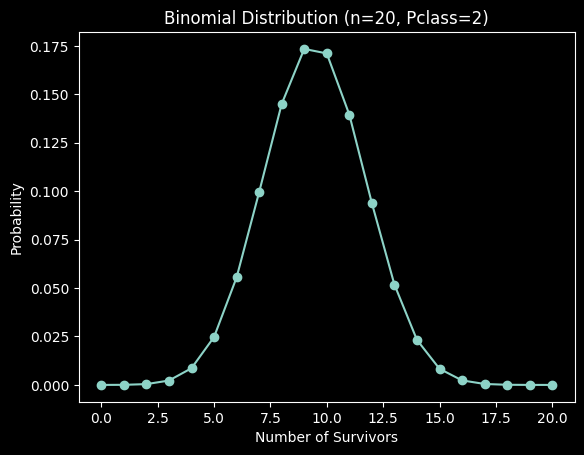

In [87]:
x = range(0, 21)
y = [comb(n, i)*(p**i)*((1-p)**(n-i)) for i in x]

plt.plot(x, y, marker='o')
plt.title("Binomial Distribution (n=20, Pclass=2)")
plt.xlabel("Number of Survivors")
plt.ylabel("Probability")
plt.show()